<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%9611_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Лабораторна робота №11

#Загинайко Павло ФІТ 2-17

#Варіант 8

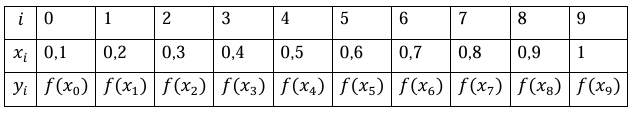

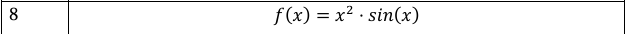

Приклад 1

In [11]:
import numpy as np
import matplotlib.pyplot as plt

Основна функція

In [12]:
def func(x):
    return (x**2) * np.sin(x)

# Вхідні дані з таблиці (від 0.1 до 1.0)
x = np.array([i * 0.1 for i in range(1, 11)])
y = np.array([func(xi) for xi in x])

print('x=', x)
print('y=', y)

x= [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y= [0.00099833 0.00794677 0.02659682 0.06230693 0.11985638 0.20327129
 0.31566667 0.4591079  0.6344948  0.84147098]


Обчислення коефіцієнтів a та b за методом найменших квадратів (МНК)

In [13]:
n = len(x)
x_mean = np.mean(x)
y_mean = np.mean(y)

a = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - (np.sum(x)**2))
b = y_mean - a * x_mean

Виведення результатів

Рівняння лінії: y = 0.9064x + -0.2314


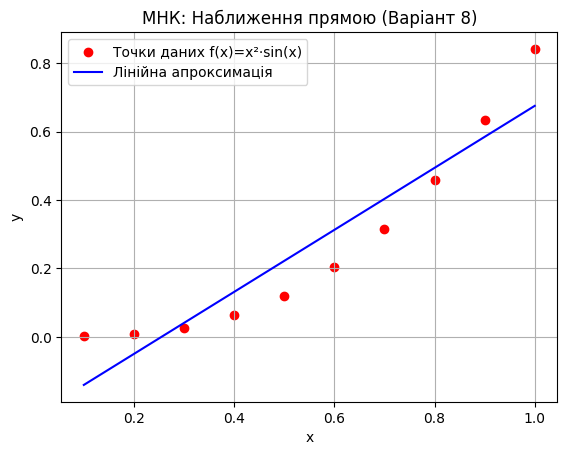

In [14]:
print(f"Рівняння лінії: y = {a:.4f}x + {b:.4f}")

# Побудова графіка
plt.scatter(x, y, color='red', label='Точки даних f(x)=x²·sin(x)')
plt.plot(x, a * x + b, color='blue', label='Лінійна апроксимація')

plt.xlabel('x')
plt.ylabel('y')
plt.title('МНК: Наближення прямою (Варіант 8)')
plt.legend()
plt.grid(True)
plt.show()

Приклад 2

In [15]:
print('x=', x)
print('y=', y)

x= [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y= [0.00099833 0.00794677 0.02659682 0.06230693 0.11985638 0.20327129
 0.31566667 0.4591079  0.6344948  0.84147098]


Використання polyfit для знаходження коефіцієнтів лінії

Рівняння лінії: y = 0.9064x + -0.2314


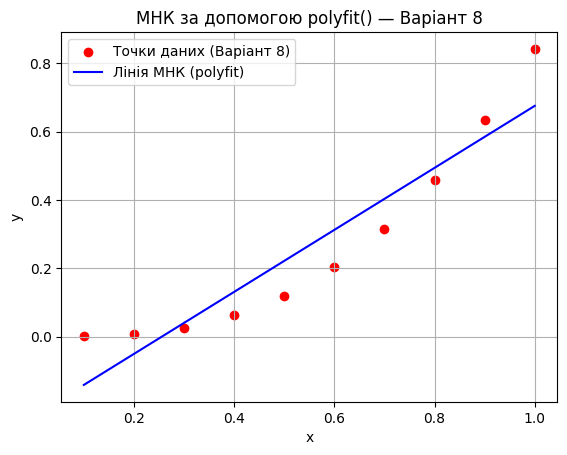

In [16]:
coefficients = np.polyfit(x, y, 1)

# Отримання коефіцієнтів: a — нахил, b — вільний член
a, b = coefficients
print(f"Рівняння лінії: y = {a:.4f}x + {b:.4f}")

# Створення поліноміальної функції для побудови графіка
polynomial = np.poly1d(coefficients)

# Побудова графіка
plt.scatter(x, y, color='red', label='Точки даних (Варіант 8)')

# Створення точок для гладкої лінії апроксимації
x_line = np.linspace(min(x), max(x), 100)
plt.plot(x_line, polynomial(x_line), color='blue', label='Лінія МНК (polyfit)')

plt.title('МНК за допомогою polyfit() — Варіант 8')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Приклад 3

In [17]:
print('x=', x)
print('y=', y)

x= [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y= [0.00099833 0.00794677 0.02659682 0.06230693 0.11985638 0.20327129
 0.31566667 0.4591079  0.6344948  0.84147098]


Використання polyfit для знаходження коефіцієнтів полінома 2-го порядку

Рівняння параболи: y = 1.2983x^2 + -0.5217x + 0.0543


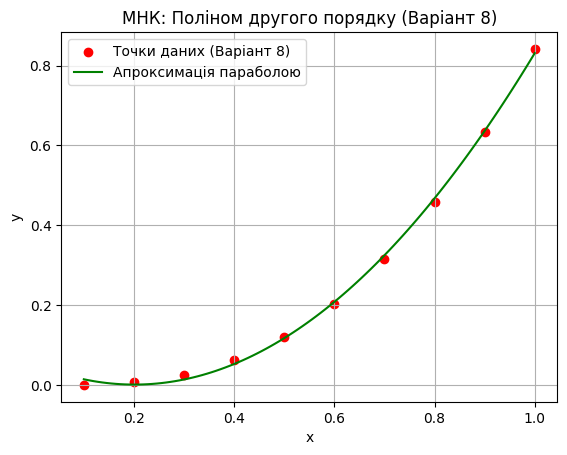

In [18]:
coefficients = np.polyfit(x, y, 2)

# Виведення результатів
a, b, c = coefficients
print(f"Рівняння параболи: y = {a:.4f}x^2 + {b:.4f}x + {c:.4f}")

# Створення поліноміальної функції для отриманих коефіцієнтів
polynomial = np.poly1d(coefficients)

# Побудова графіка
plt.scatter(x, y, color='red', label='Точки даних (Варіант 8)')

# Точки для побудови гладкої кривої параболи
x_line = np.linspace(min(x), max(x), 100)
plt.plot(x_line, polynomial(x_line), color='green', label='Апроксимація параболою')

plt.title('МНК: Поліном другого порядку (Варіант 8)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Приклад 4

In [19]:
from scipy.optimize import least_squares

print('x=', x)
print('y=', y)

x= [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
y= [0.00099833 0.00794677 0.02659682 0.06230693 0.11985638 0.20327129
 0.31566667 0.4591079  0.6344948  0.84147098]


Функція для мінімізації

Коефіцієнти: a0 = 0.0543, a1 = -0.5217, a2 = 1.2983


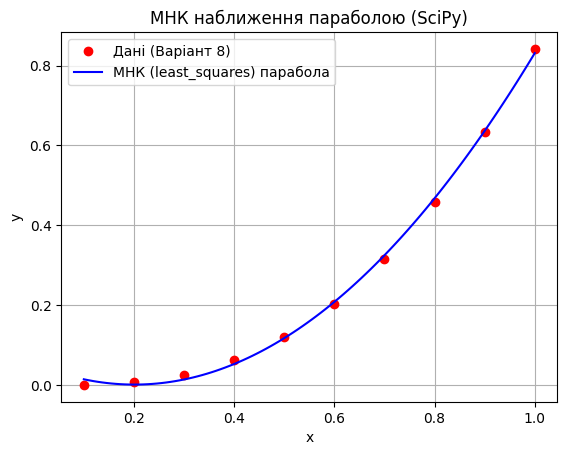

In [20]:
def fun(a, x, y):
    return a[0] + a[1] * x + a[2] * x**2 - y

# Початкові наближення коефіцієнтів (будь-які стартові значення)
a0 = np.array([1, 1, 1])

# Використовуємо least_squares для знаходження оптимальних параметрів
res_lsq = least_squares(fun, x0=a0, args=(x, y))

# Отримані коефіцієнти
a_opt = res_lsq.x
print("Коефіцієнти: a0 = %.4f, a1 = %.4f, a2 = %.4f" % tuple(a_opt))

# Функція апроксимації (парабола) з отриманими коефіцієнтами
def f_approx(x_val):
    return a_opt[0] + a_opt[1] * x_val + a_opt[2] * x_val**2

# Побудова графіка
x_p = np.linspace(min(x), max(x), 100)
y_p = f_approx(x_p)

plt.plot(x, y, 'ro', label='Дані (Варіант 8)')
plt.plot(x_p, y_p, 'b', label='МНК (least_squares) парабола')

plt.title("МНК наближення параболою (SciPy)")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()